Import the necessary libraries

In [11]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np



In [12]:
# Load the wind dataset
wine = load_wine()

# Convert the dataset to a Pandas DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

In [13]:
# Display the first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


The Wine dataset is a multiclass classification dataset containing 178 wine samples and 13 numerical features representing chemical measurements such as alcohol, malic acid, magnesium, flavanoids, color intensity and proline.

In [15]:
# Add the target/class column
df["target"] = wine.target

# Number of samples and features
print("Number of samples:", wine.data.shape[0])
print("Number of features:", wine.data.shape[1])

# Number of classes
print("Number of classes:", len(wine.target_names))

# Class names
print("Class names:", wine.target_names)

# Feature names
print("Feature names:", wine.feature_names)

# Class distribution
print("\nClass distribution:")
print(df["target"].value_counts().sort_index())

Number of samples: 178
Number of features: 13
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


The class distribution shows the number of wine samples belonging to each target class. That is out of the 178 samples, 59 samples belong in Class 0, 71 in Class 1, and 48 in Class 2, showing that the classclass 0 has the higgest number. The clases are not very balanced.

In [17]:
#verify what features are in each class
# Display samples belonging to Class 0
df[df["target"] == 0].head()



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
# Display samples belonging to Class 1
df[df["target"] == 1].head()



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1
60,12.33,1.10,2.28,16.0,101.0,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680.0,1
61,12.64,1.36,2.02,16.8,100.0,2.02,1.41,0.53,0.62,5.75,0.98,1.59,450.0,1
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,1
63,12.37,1.13,2.16,19.0,87.0,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420.0,1


In [19]:
# Display samples belonging to Class 2
df[df["target"] == 2].head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2
131,12.88,2.99,2.40,20.0,104.0,1.30,1.22,0.24,0.83,5.40,0.74,1.42,530.0,2
132,12.81,2.31,2.40,24.0,98.0,1.15,1.09,0.27,0.83,5.70,0.66,1.36,560.0,2
133,12.70,3.55,2.36,21.5,106.0,1.70,1.20,0.17,0.84,5.00,0.78,1.29,600.0,2
134,12.51,1.24,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.45,0.75,1.51,650.0,2


**Apply Sampling Techniques**

In [23]:
# Perform simple random sampling
random_sample = df.sample(n=50, random_state=42)


# Check class distribution
print("Simple Random Sampling:")
print(random_sample["target"].value_counts().sort_index())

Simple Random Sampling:
target
0    17
1    20
2    13
Name: count, dtype: int64


Note that simple random sampling gives equall opportunity for each class to be selected.

In [21]:
# Stratified Sampling with 50 samples
from sklearn.model_selection import train_test_split
_, stratified_sample = train_test_split(
    df,
    test_size=50,
    stratify=df["target"],
    random_state=42
)

# Check class distribution
print("Stratified Sampling:")
print(stratified_sample["target"].value_counts().sort_index())

Stratified Sampling:
target
0    17
1    20
2    13
Name: count, dtype: int64


Note that stratified sampling selects samples while trying to maintain the same class proportions as the original dataset.

<Axes: xlabel='target'>

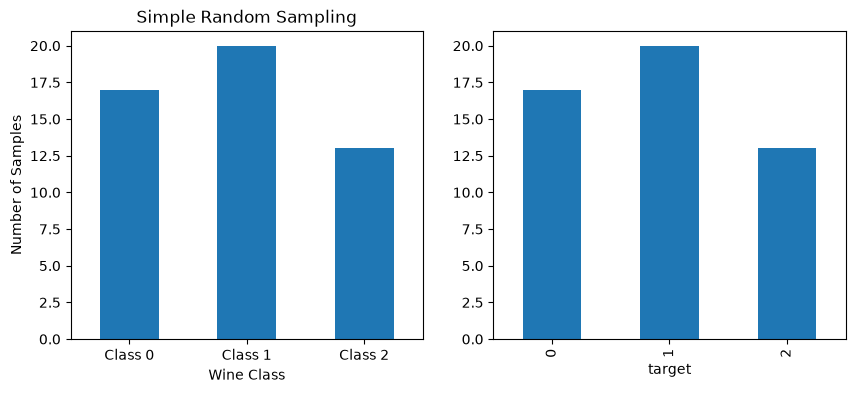

In [24]:
#Visualize the class distribution for each subset and discuss the differences
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Simple Random Sampling
random_sample["target"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Simple Random Sampling")
axes[0].set_xlabel("Wine Class")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xticklabels(["Class 0", "Class 1", "Class 2"], rotation=0)

# Stratified Sampling
stratified_sample["target"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)

Both sampling have equal and thesame sample sizes

In [25]:
#Verify the initial class distribution
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Original class distribution:")
print(y.value_counts().sort_index())

Original class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [26]:
# Combine X and y
wine_df = X.copy()
wine_df["target"] = y

# Keep all samples from Classes 0 and 1
class_0 = wine_df[wine_df["target"] == 0]
class_1 = wine_df[wine_df["target"] == 1]

# Reduce Class 2 to only 10 samples
class_2 = wine_df[wine_df["target"] == 2].sample(
    n=10,
    random_state=42
)

# Create imbalanced dataset
imbalanced_df = pd.concat(
    [class_0, class_1, class_2]
).sample(frac=1, random_state=42).reset_index(drop=True)

print("Imbalanced class distribution:")
print(imbalanced_df["target"].value_counts().sort_index())

Imbalanced class distribution:
target
0    59
1    71
2    10
Name: count, dtype: int64


This has create an imbalance in the classess.

In [27]:
#Split the data
X_imbalanced = imbalanced_df.drop("target", axis=1)
y_imbalanced = imbalanced_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_imbalanced,
    y_imbalanced,
    test_size=0.30,
    random_state=42,
    stratify=y_imbalanced
)

print("Training distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting distribution:")
print(y_test.value_counts().sort_index())

Training distribution:
target
0    41
1    50
2     7
Name: count, dtype: int64

Testing distribution:
target
0    18
1    21
2     3
Name: count, dtype: int64


In [28]:
#Apply the SMOTE which will create additional sample sizes to balance up classes
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts().sort_index())

Before SMOTE:
target
0    41
1    50
2     7
Name: count, dtype: int64

After SMOTE:
target
0    50
1    50
2    50
Name: count, dtype: int64


**Train a Random Forest Classifier on both the imbalanced and balanced datasets and compare their performance using Precision, Recall, and F1-Score.**

In [31]:
#Train Random Forest on the imbalanced data

rf_imbalanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_imbalanced.fit(X_train, y_train)

y_pred_imbalanced = rf_imbalanced.predict(X_test)

print("Random Forest - Imbalanced Data")
print(classification_report(y_test, y_pred_imbalanced))

Random Forest - Imbalanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.67      0.80         3

    accuracy                           0.98        42
   macro avg       0.98      0.89      0.93        42
weighted avg       0.98      0.98      0.97        42



In [32]:
#Train Random Forest on the SMOTE-balanced data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_balanced.fit(X_train_smote, y_train_smote)

y_pred_balanced = rf_balanced.predict(X_test)

print("Random Forest - SMOTE Balanced Data")
print(classification_report(y_test, y_pred_balanced))

Random Forest - SMOTE Balanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.75      1.00      0.86         3

    accuracy                           0.98        42
   macro avg       0.92      0.98      0.94        42
weighted avg       0.98      0.98      0.98        42



Both Random Forest models achieved 98% accuracy. However, SMOTE improved the detection of the minority Class 2, increasing its recall from 0.67 to 1.00 and F1-score from 0.80 to 0.86. Macro recall also increased from 0.89 to 0.98. Although Class 2 precision decreased from 1.00 to 0.75, the results suggest that SMOTE helped the model identify the minority class more effectively. Since Class 2 had only three test samples, these results should be interpreted cautiously.

**Labeling using a simple heuristic**


In [33]:
# Create heuristic labels based on alcohol content

df["heuristic_label"] = df["alcohol"].apply(
    lambda x: "High Alcohol" if x >= 13 else "Low Alcohol"
)

# Display the first 10 rows
df[["alcohol", "target", "heuristic_label"]].head(10)

,alcohol,target,heuristic_label
0,14.23,0,High Alcohol
1,13.20,0,High Alcohol
2,13.16,0,High Alcohol
3,14.37,0,High Alcohol
4,13.24,0,High Alcohol
5,14.20,0,High Alcohol
6,14.39,0,High Alcohol
7,14.06,0,High Alcohol
8,14.83,0,High Alcohol
9,13.86,0,High Alcohol


In [34]:
print("Heuristic Label Distribution:")
print(df["heuristic_label"].value_counts())

Heuristic Label Distribution:
heuristic_label
High Alcohol    92
Low Alcohol     86
Name: count, dtype: int64


In [35]:
#compare the heuristic with the actual
pd.crosstab(
    df["target"],
    df["heuristic_label"]
)

heuristic_label,High Alcohol,Low Alcohol
target,,
0,57,2
1,8,63
2,27,21


A simple heuristic was created using the alcohol feature. Wines with an alcohol value greater than or equal to 13 were labeled “High Alcohol,” while wines below 13 were labeled “Low Alcohol.” Although this method is simple and easy to interpret, it may not accurately represent the actual wine classes. A single threshold ignores other important features, and the choice of 13 is arbitrary.

In [ ]:
**Evaluate Model Performance**


In [36]:
#the original dataset data spliting

X = wine.data
y = wine.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 124
Testing samples: 54


In [38]:
#Train the model
# Create Decision Tree model

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Get predicted probabilities
y_prob = dt_model.predict_proba(X_test)

In [40]:
#Calculate ROC Curve and AUC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

# Store ROC and AUC results
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    
    roc_auc[i] = auc(fpr[i], tpr[i])

# Print AUC for each class
for i in range(3):
    print(f"Class {i} AUC: {roc_auc[i]:.3f}")

Class 0 AUC: 0.972
Class 1 AUC: 0.970
Class 2 AUC: 0.967


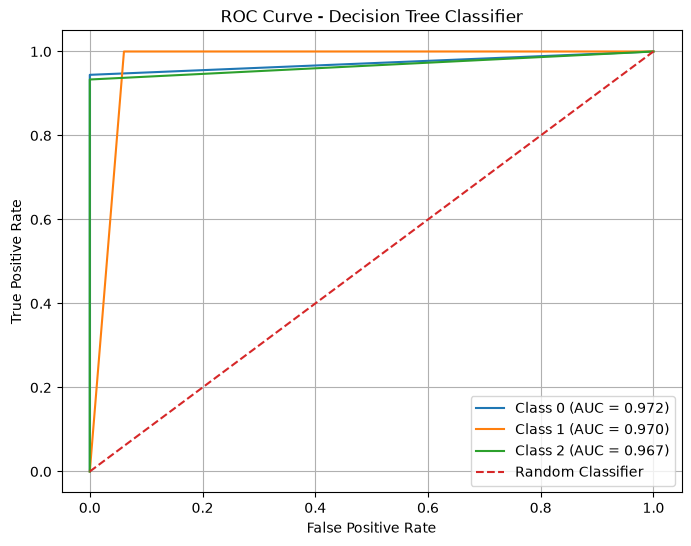

In [41]:
#Plot the ROC Curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend()
plt.grid()

plt.show()

In [42]:
#Calculate an overall AUC score
from sklearn.metrics import roc_auc_score

overall_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Overall Macro AUC:", round(overall_auc, 3))

Overall Macro AUC: 0.97


The ROC curve shows how well the Decision Tree distinguishes each wine class from the other classes. A curve closer to the top-left corner indicates better classification performance. The diagonal line represents performance similar to random classification.

**Logistic Regression**


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


original_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train on original training data
original_model.fit(X_train, y_train)

# Predictions
y_pred_original = original_model.predict(X_test)

print("Original Dataset:")
print(classification_report(y_test, y_pred_original))

Original Dataset:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [46]:
# Set random seed
np.random.seed(42)

# Calculate standard deviation of each feature
feature_std = X_train.std(axis=0)

# Generate small Gaussian noise
noise = np.random.normal(
    loc=0,
    scale=0.05 * feature_std,
    size=X_train.shape
)

# Create noisy copies of training observations
X_train_noisy = X_train + noise

print("Original training shape:", X_train.shape)
print("Noisy data shape:", X_train_noisy.shape)

Original training shape: (124, 13)
Noisy data shape: (124, 13)


In [47]:
# Combine original and augmented features
X_train_augmented = np.vstack([
    X_train,
    X_train_noisy
])

# The noisy observations keep the same labels
y_train_augmented = np.concatenate([
    y_train,
    y_train
])

print("Original training samples:", len(X_train))
print("Augmented training samples:", len(X_train_augmented))

Original training samples: 124
Augmented training samples: 248


In [48]:
#Train Logistic Regression on augmented data
augmented_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train using augmented dataset
augmented_model.fit(
    X_train_augmented,
    y_train_augmented
)

# Predict the SAME original test data
y_pred_augmented = augmented_model.predict(X_test)

print("Augmented Dataset:")
print(classification_report(y_test, y_pred_augmented))

Augmented Dataset:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



The Logistic Regression model achieved 98% accuracy on both the original and augmented datasets. Precision, recall, and F1-scores were also identical. Therefore, adding small amounts of noise did not affect the model’s performance. This may be because the original Wine dataset already contains features that clearly distinguish the classes, and the model was already performing very well. The augmentation may still improve robustness, but no measurable improvement was observed on this test set.

Data augmentation was performed by adding small Gaussian noise to the training features while keeping the original class labels. This increased the training dataset from 124 to 248 observations. Logistic Regression was then trained separately on the original and augmented datasets and evaluated using the same unchanged test set. Comparing accuracy, precision, recall, and F1-score shows whether the additional noisy observations improved the model's ability to generalize. Small amounts of noise may improve robustness, while excessive noise could reduce performance by creating unrealistic observations.